<a href="https://colab.research.google.com/github/prabeshbchettri/Support_Vector_Machine-SVM-_AI/blob/main/AI_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import cv2
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 60)
print("Libraries imported successfully!")
print("=" * 60)

Libraries imported successfully!


In [2]:
# ============================================================
# CELL 2: MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

print("Mounting Google Drive...")
drive.mount('/content/drive')

print("\nGoogle Drive mounted successfully!")

Mounting Google Drive...
Mounted at /content/drive

Google Drive mounted successfully!


In [3]:
# ============================================================
# CELL 3: DATASET CONFIGURATION
# ============================================================

dataset_path = "/content/drive/MyDrive/whole_images"

# Check whether the folder exists
if os.path.exists(dataset_path):
    print("Dataset folder found!")
    print("Path:", dataset_path)
else:
    print("ERROR: Dataset folder not found!")
    print("Please check dataset_path.")

Dataset folder found!
Path: /content/drive/MyDrive/whole_images


In [4]:
# ============================================================
# CELL 4: LOAD UTKFACE DATASET METADATA
# ============================================================

print("=" * 60)
print("Loading UTKFace metadata...")
print("=" * 60)

data = []

files = os.listdir(dataset_path)

print(f"Total files found in folder: {len(files)}")

for filename in tqdm(files, desc="Reading filenames"):

    # Only process image files
    if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    try:
        # UTKFace format:
        # age_gender_race_date.jpg
        parts = filename.split('_')

        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])

        # Keep valid values
        if age < 0 or age > 116:
            continue

        if gender not in [0, 1]:
            continue

        if race not in [0, 1, 2, 3, 4]:
            continue

        data.append({
            "filename": filename,
            "age": age,
            "gender": gender,
            "race": race
        })

    except:
        # Ignore files that do not follow UTKFace format
        continue

df = pd.DataFrame(data)

print("\n" + "=" * 60)
print("DATASET LOADING COMPLETE")
print("=" * 60)

print(f"Valid images: {len(df)}")
print(f"Columns: {list(df.columns)}")

Loading UTKFace metadata...
Total files found in folder: 24125


Reading filenames:   0%|          | 0/24125 [00:00<?, ?it/s]


DATASET LOADING COMPLETE
Valid images: 24118
Columns: ['filename', 'age', 'gender', 'race']


In [5]:
# ============================================================
# CELL 5: DATASET DISTRIBUTION
# ============================================================

print("=" * 60)
print("GENDER DISTRIBUTION")
print("=" * 60)

gender_counts = df["gender"].value_counts().sort_index()

print(gender_counts)

print("\nPercentage:")
print(
    (gender_counts / len(df) * 100)
    .round(2)
)

print("\n" + "=" * 60)
print("RACE DISTRIBUTION")
print("=" * 60)

race_counts = df["race"].value_counts().sort_index()

print(race_counts)

print("\nPercentage:")
print(
    (race_counts / len(df) * 100)
    .round(2)
)

print("\n" + "=" * 60)
print("AGE STATISTICS")
print("=" * 60)

print(df["age"].describe())

GENDER DISTRIBUTION
gender
0    12597
1    11521
Name: count, dtype: int64

Percentage:
gender
0    52.23
1    47.77
Name: count, dtype: float64

RACE DISTRIBUTION
race
0    10237
1     4558
2     3586
3     4027
4     1710
Name: count, dtype: int64

Percentage:
race
0    42.45
1    18.90
2    14.87
3    16.70
4     7.09
Name: count, dtype: float64

AGE STATISTICS
count    24118.000000
mean        33.059665
std         20.144232
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64


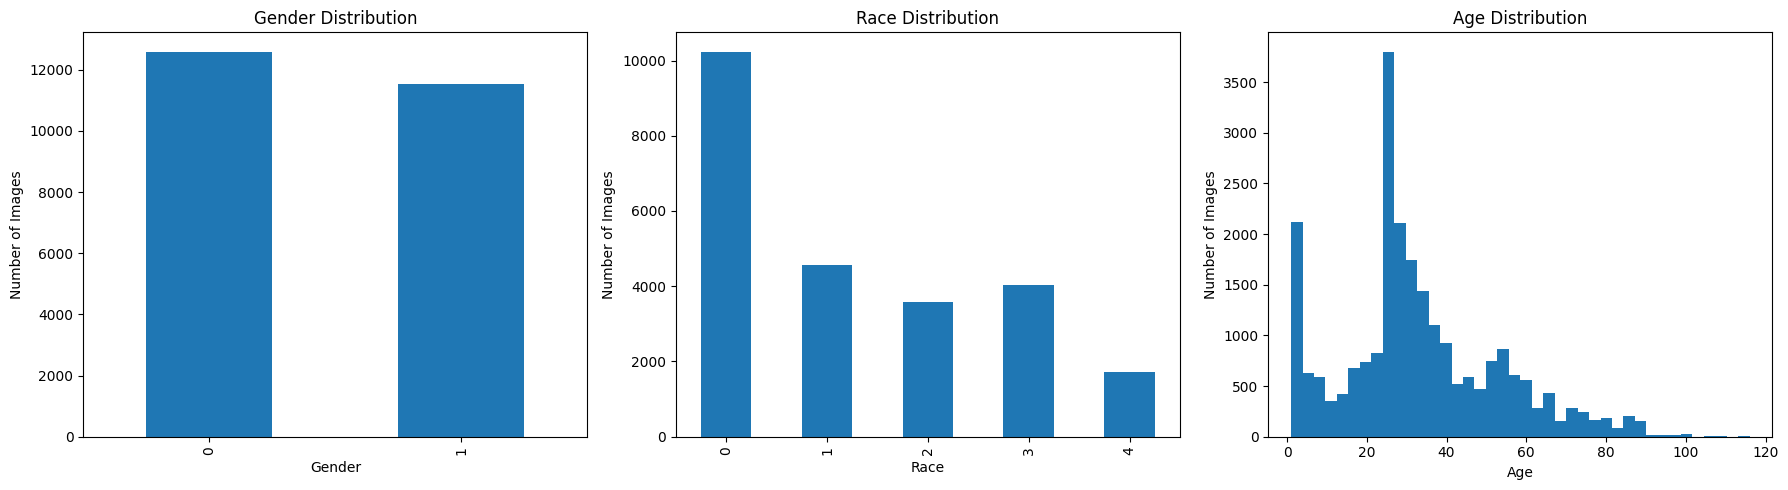

In [6]:
# ============================================================
# CELL 6: VISUALIZE DATA DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------- Gender ----------------
gender_counts.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Gender Distribution")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Number of Images")

# ---------------- Race ----------------
race_counts.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Race Distribution")
axes[1].set_xlabel("Race")
axes[1].set_ylabel("Number of Images")

# ---------------- Age ----------------
axes[2].hist(
    df["age"],
    bins=40
)

axes[2].set_title("Age Distribution")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# CELL 7: LABEL MAPPING
# ============================================================

gender_names = {
    0: "Female",
    1: "Male"
}

race_names = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Others"
}

print("Gender mapping:")
for key, value in gender_names.items():
    print(f"{key} -> {value}")

print("\nRace mapping:")
for key, value in race_names.items():
    print(f"{key} -> {value}")

Gender mapping:
0 -> Female
1 -> Male

Race mapping:
0 -> White
1 -> Black
2 -> Asian
3 -> Indian
4 -> Others


In [1]:
# ============================================================
# CELL 8: IMAGE PREPROCESSING + HOG FEATURE EXTRACTION
# ============================================================

IMG_SIZE = (128, 128)

# HOG configuration
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)

X = []
y_gender = []
y_race = []
y_age = []

failed_images = []

print("=" * 60)
print("STARTING IMAGE PREPROCESSING + HOG")
print("=" * 60)

start_time = time.time()

for _, row in tqdm(
    df.iterrows(),
    total=len(df),
    desc="Processing images"
):

    image_path = os.path.join(
        dataset_path,
        row["filename"]
    )

    # Read image
    image = cv2.imread(image_path)

    if image is None:
        failed_images.append(row["filename"])
        continue

    # Resize
    image = cv2.resize(
        image,
        IMG_SIZE
    )

    # Convert BGR → grayscale
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # HOG feature extraction
    features = hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys"
    )

    X.append(features)

    y_gender.append(row["gender"])
    y_race.append(row["race"])
    y_age.append(row["age"])

# Convert to NumPy arrays
X = np.asarray(X, dtype=np.float32)

y_gender = np.asarray(
    y_gender,
    dtype=np.int32
)

y_race = np.asarray(
    y_race,
    dtype=np.int32
)

y_age = np.asarray(
    y_age,
    dtype=np.float32
)

elapsed = time.time() - start_time

print("\n" + "=" * 60)
print("HOG EXTRACTION COMPLETE")
print("=" * 60)

print(f"Images processed : {len(X)}")
print(f"Images failed    : {len(failed_images)}")
print(f"HOG feature shape: {X.shape}")
print(f"Time taken       : {elapsed / 60:.2f} minutes")

STARTING IMAGE PREPROCESSING + HOG


NameError: name 'time' is not defined

In [ ]:
# ============================================================
# CELL 9: SAVE HOG FEATURES
# ============================================================

feature_file = "/content/drive/MyDrive/UTKFace/hog_features.npz"

np.savez_compressed(
    feature_file,
    X=X,
    y_gender=y_gender,
    y_race=y_race,
    y_age=y_age
)

print("=" * 60)
print("HOG FEATURES SAVED")
print("=" * 60)

print("File:", feature_file)

In [ ]:
# ============================================================
# CELL 10: CHECK CLASS IMBALANCE
# ============================================================

print("=" * 60)
print("CLASS BALANCE ANALYSIS")
print("=" * 60)

print("\nGender:")
for cls, count in zip(
    *np.unique(y_gender, return_counts=True)
):
    percentage = count / len(y_gender) * 100
    print(
        f"{gender_names[cls]:<10} : "
        f"{count:>6} ({percentage:.2f}%)"
    )

print("\nRace:")

unique_races, race_counts = np.unique(
    y_race,
    return_counts=True
)

for cls, count in zip(
    unique_races,
    race_counts
):
    percentage = count / len(y_race) * 100

    print(
        f"{race_names[cls]:<10} : "
        f"{count:>6} ({percentage:.2f}%)"
    )

In [ ]:
# ============================================================
# CELL 11: CREATE AGE GROUPS FOR STRATIFIED SPLIT
# ============================================================

age_bins = [
    -1,
    12,
    19,
    39,
    59,
    116
]

age_labels = [
    "Child",
    "Teen",
    "Young_Adult",
    "Adult",
    "Senior"
]

age_groups = pd.cut(
    y_age,
    bins=age_bins,
    labels=age_labels
)

print("=" * 60)
print("AGE GROUP DISTRIBUTION")
print("=" * 60)

print(
    pd.Series(age_groups)
    .value_counts()
    .sort_index()
)

In [ ]:
# ============================================================
# CELL 12: STRATIFIED TRAIN / TEST SPLIT
# ============================================================

print("=" * 60)
print("CREATING STRATIFIED TRAIN/TEST SPLIT")
print("=" * 60)

# Combine race and age group for stratification
stratify_labels = np.array([
    f"{race}_{age_group}"
    for race, age_group in zip(
        y_race,
        age_groups
    )
])

# Check whether any combination is too rare
label_counts = pd.Series(
    stratify_labels
).value_counts()

print("Minimum samples in a stratification group:",
      label_counts.min())

# Split indices
indices = np.arange(len(X))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=stratify_labels
)

print("\nSplit completed!")
print(f"Training samples: {len(train_idx)}")
print(f"Testing samples : {len(test_idx)}")

In [ ]:
# ============================================================
# CELL 13: CREATE TRAIN / TEST DATA
# ============================================================

X_train = X[train_idx]
X_test = X[test_idx]

# Gender
yg_train = y_gender[train_idx]
yg_test = y_gender[test_idx]

# Race
yr_train = y_race[train_idx]
yr_test = y_race[test_idx]

# Age
ya_train = y_age[train_idx]
ya_test = y_age[test_idx]

print("=" * 60)
print("TRAIN / TEST DATA CREATED")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nGender:")
print("Train:", yg_train.shape)
print("Test :", yg_test.shape)

print("\nRace:")
print("Train:", yr_train.shape)
print("Test :", yr_test.shape)

print("\nAge:")
print("Train:", ya_train.shape)
print("Test :", ya_test.shape)

In [ ]:
# ============================================================
# CELL 14: VERIFY RACE DISTRIBUTION AFTER SPLIT
# ============================================================

print("=" * 60)
print("RACE DISTRIBUTION - TRAINING SET")
print("=" * 60)

train_race_counts = pd.Series(
    yr_train
).value_counts().sort_index()

print(train_race_counts)

print("\n" + "=" * 60)
print("RACE DISTRIBUTION - TEST SET")
print("=" * 60)

test_race_counts = pd.Series(
    yr_test
).value_counts().sort_index()

print(test_race_counts)

In [ ]:
# ============================================================
# CELL 15: FEATURE STANDARDIZATION
# ============================================================

print("=" * 60)
print("STANDARDIZING HOG FEATURES")
print("=" * 60)

start_time = time.time()

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(
    X_train
)

# Transform test data using same scaler
X_test_scaled = scaler.transform(
    X_test
)

elapsed = time.time() - start_time

print("Standardization completed!")
print(f"Time taken: {elapsed:.2f} seconds")

print("\nTraining shape:", X_train_scaled.shape)
print("Testing shape :", X_test_scaled.shape)

In [ ]:
# ============================================================
# CELL 16: GENDER SVM CLASSIFIER
# ============================================================

print("=" * 60)
print("TRAINING GENDER SVM")
print("=" * 60)

start_time = time.time()

gender_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    cache_size=4000
)

gender_model.fit(
    X_train_scaled,
    yg_train
)

elapsed = time.time() - start_time

print("\nGender SVM training completed!")
print(f"Training time: {elapsed / 60:.2f} minutes")

In [ ]:
# ============================================================
# CELL 17: GENDER SVM EVALUATION
# ============================================================

print("=" * 60)
print("EVALUATING GENDER MODEL")
print("=" * 60)

gender_pred = gender_model.predict(
    X_test_scaled
)

gender_accuracy = accuracy_score(
    yg_test,
    gender_pred
)

print(f"\nGender Accuracy: {gender_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        yg_test,
        gender_pred,
        target_names=[
            "Female",
            "Male"
        ]
    )
)

# Confusion matrix
cm = confusion_matrix(
    yg_test,
    gender_pred
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Gender SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Female", "Male"]
)

plt.yticks(
    [0, 1],
    ["Female", "Male"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [ ]:
# ============================================================
# CELL 18: RACE SVM CLASSIFIER
# WITH CLASS IMBALANCE HANDLING
# ============================================================

print("=" * 60)
print("TRAINING RACE SVM")
print("=" * 60)

print("\nClass imbalance handling:")
print("Using class_weight='balanced'")

start_time = time.time()

race_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",

    # IMPORTANT:
    # Automatically gives greater importance
    # to minority race classes.
    class_weight="balanced",

    cache_size=4000
)

race_model.fit(
    X_train_scaled,
    yr_train
)

elapsed = time.time() - start_time

print("\nRace SVM training completed!")
print(f"Training time: {elapsed / 60:.2f} minutes")

In [ ]:
# ============================================================
# CELL 19: RACE SVM EVALUATION
# ============================================================

print("=" * 60)
print("EVALUATING RACE MODEL")
print("=" * 60)

race_pred = race_model.predict(
    X_test_scaled
)

race_accuracy = accuracy_score(
    yr_test,
    race_pred
)

print(f"\nRace Accuracy: {race_accuracy:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        yr_test,
        race_pred,
        labels=[0, 1, 2, 3, 4],
        target_names=[
            "White",
            "Black",
            "Asian",
            "Indian",
            "Others"
        ]
    )
)

# Confusion matrix
cm = confusion_matrix(
    yr_test,
    race_pred,
    labels=[0, 1, 2, 3, 4]
)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Race SVM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    range(5),
    ["White", "Black", "Asian", "Indian", "Others"],
    rotation=30
)

plt.yticks(
    range(5),
    ["White", "Black", "Asian", "Indian", "Others"]
)

for i in range(5):
    for j in range(5):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 20: AGE SUPPORT VECTOR REGRESSION
# ============================================================

print("=" * 60)
print("TRAINING AGE SVR")
print("=" * 60)

print("""
Age is a regression problem.
Therefore class_weight is not applicable.

Age imbalance is handled through:
1. Age-group stratification
2. Representative train/test split
""")

start_time = time.time()

age_model = SVR(
    kernel="rbf",
    C=10,
    gamma="scale",
    epsilon=0.1,
    cache_size=4000
)

age_model.fit(
    X_train_scaled,
    ya_train
)

elapsed = time.time() - start_time

print("\nAge SVR training completed!")
print(f"Training time: {elapsed / 60:.2f} minutes")

In [ ]:
# ============================================================
# CELL 21: AGE SVR EVALUATION
# ============================================================

print("=" * 60)
print("EVALUATING AGE SVR")
print("=" * 60)

age_pred = age_model.predict(
    X_test_scaled
)

# Metrics
mae = mean_absolute_error(
    ya_test,
    age_pred
)

rmse = np.sqrt(
    mean_squared_error(
        ya_test,
        age_pred
    )
)

r2 = r2_score(
    ya_test,
    age_pred
)

print("\n" + "=" * 50)
print("AGE SVR RESULTS")
print("=" * 50)

print(f"MAE  : {mae:.3f} years")
print(f"RMSE : {rmse:.3f} years")
print(f"R²   : {r2:.3f}")

In [ ]:
# ============================================================
# CELL 22: ACTUAL VS PREDICTED AGE
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    ya_test,
    age_pred,
    alpha=0.4
)

# Perfect prediction line
min_age = min(
    ya_test.min(),
    age_pred.min()
)

max_age = max(
    ya_test.max(),
    age_pred.max()
)

plt.plot(
    [min_age, max_age],
    [min_age, max_age],
    linestyle="--"
)

plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")

plt.title(
    "SVR: Actual Age vs Predicted Age"
)

plt.show()

In [ ]:
# ============================================================
# CELL 23: AGE PERFORMANCE BY AGE GROUP
# ============================================================

results_df = pd.DataFrame({
    "actual_age": ya_test,
    "predicted_age": age_pred
})

results_df["age_group"] = pd.cut(
    results_df["actual_age"],
    bins=[-1, 12, 19, 39, 59, 116],
    labels=[
        "Child",
        "Teen",
        "Young Adult",
        "Adult",
        "Senior"
    ]
)

print("=" * 60)
print("AGE PERFORMANCE BY AGE GROUP")
print("=" * 60)

for group in results_df["age_group"].cat.categories:

    group_data = results_df[
        results_df["age_group"] == group
    ]

    if len(group_data) == 0:
        continue

    group_mae = mean_absolute_error(
        group_data["actual_age"],
        group_data["predicted_age"]
    )

    print(
        f"{group:<15} "
        f"Samples: {len(group_data):>5} | "
        f"MAE: {group_mae:.2f} years"
    )

In [ ]:
# ============================================================
# CELL 24: SAVE TRAINED MODELS
# ============================================================

model_directory = "/content/drive/MyDrive/UTKFace/SVM_Models"

os.makedirs(
    model_directory,
    exist_ok=True
)

print("=" * 60)
print("SAVING MODELS")
print("=" * 60)

joblib.dump(
    scaler,
    os.path.join(
        model_directory,
        "hog_scaler.pkl"
    )
)

print("✓ Scaler saved")

joblib.dump(
    gender_model,
    os.path.join(
        model_directory,
        "gender_svm.pkl"
    )
)

print("✓ Gender SVM saved")

joblib.dump(
    race_model,
    os.path.join(
        model_directory,
        "race_svm.pkl"
    )
)

print("✓ Race SVM saved")

joblib.dump(
    age_model,
    os.path.join(
        model_directory,
        "age_svr.pkl"
    )
)

print("✓ Age SVR saved")

print("\nAll models saved successfully!")
print("Location:", model_directory)

In [ ]:
# ============================================================
# CELL 25: FINAL FACIAL ATTRIBUTE PREDICTION FUNCTION
# ============================================================

def extract_hog_from_face(face_image):

    # Resize
    image = cv2.resize(
        face_image,
        IMG_SIZE
    )

    # Convert to grayscale
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # Extract HOG
    features = hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys"
    )

    return features


def predict_face(face_image):

    # Extract HOG
    features = extract_hog_from_face(
        face_image
    )

    # Convert to 2D
    features = features.reshape(
        1,
        -1
    )

    # Scale using trained scaler
    features_scaled = scaler.transform(
        features
    )

    # Gender prediction
    gender_prediction = gender_model.predict(
        features_scaled
    )[0]

    # Race prediction
    race_prediction = race_model.predict(
        features_scaled
    )[0]

    # Age prediction
    age_prediction = age_model.predict(
        features_scaled
    )[0]

    return {
        "gender": gender_names[
            gender_prediction
        ],

        "race": race_names[
            race_prediction
        ],

        "age": round(
            float(age_prediction)
        )
    }


print("Prediction functions created successfully!")

In [ ]:
# ============================================================
# CELL 26: TEST ONE IMAGE
# ============================================================

test_row = df.iloc[0]

test_image_path = os.path.join(
    dataset_path,
    test_row["filename"]
)

test_image = cv2.imread(
    test_image_path
)

result = predict_face(
    test_image
)

print("=" * 60)
print("PREDICTION RESULT")
print("=" * 60)

print(f"Gender : {result['gender']}")
print(f"Race   : {result['race']}")
print(f"Age    : {result['age']} years")

print("\nActual values:")
print(f"Gender : {gender_names[test_row['gender']]}")
print(f"Race   : {race_names[test_row['race']]}")
print(f"Age    : {test_row['age']} years")

In [ ]:
# ============================================================
# CELL 27: OPENCV FACE DETECTOR
# ============================================================

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

print("OpenCV Haar Cascade face detector loaded!")

In [ ]:
# ============================================================
# CELL 28: UPLOAD GROUP PHOTO
# ============================================================

from google.colab import files

print("Please upload a group photo...")

uploaded = files.upload()

photo_name = list(
    uploaded.keys()
)[0]

print("\nUploaded:", photo_name)

In [ ]:
# ============================================================
# CELL 29: GROUP PHOTO FACIAL ATTRIBUTE ANALYSIS
# ============================================================

group_image = cv2.imread(
    photo_name
)

gray = cv2.cvtColor(
    group_image,
    cv2.COLOR_BGR2GRAY
)

print("Detecting faces...")

faces = face_detector.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(50, 50)
)

print(f"\nFaces detected: {len(faces)}")

output_image = group_image.copy()

for i, (x, y, w, h) in enumerate(faces):

    # Crop detected face
    face = group_image[
        y:y+h,
        x:x+w
    ]

    # Predict attributes
    result = predict_face(face)

    gender = result["gender"]
    race = result["race"]
    age = result["age"]

    # Draw rectangle
    cv2.rectangle(
        output_image,
        (x, y),
        (x+w, y+h),
        (0, 255, 0),
        2
    )

    # Text
    text = (
        f"{gender} | "
        f"{race} | "
        f"{age}"
    )

    cv2.putText(
        output_image,
        text,
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

    print(
        f"Person {i+1} → "
        f"{gender} | {race} | {age} years"
    )

In [ ]:
# ============================================================
# CELL 30: DISPLAY FINAL RESULT
# ============================================================

plt.figure(figsize=(14, 10))

plt.imshow(
    cv2.cvtColor(
        output_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Facial Attribute Analysis using HOG + SVM"
)

plt.axis("off")

plt.show()